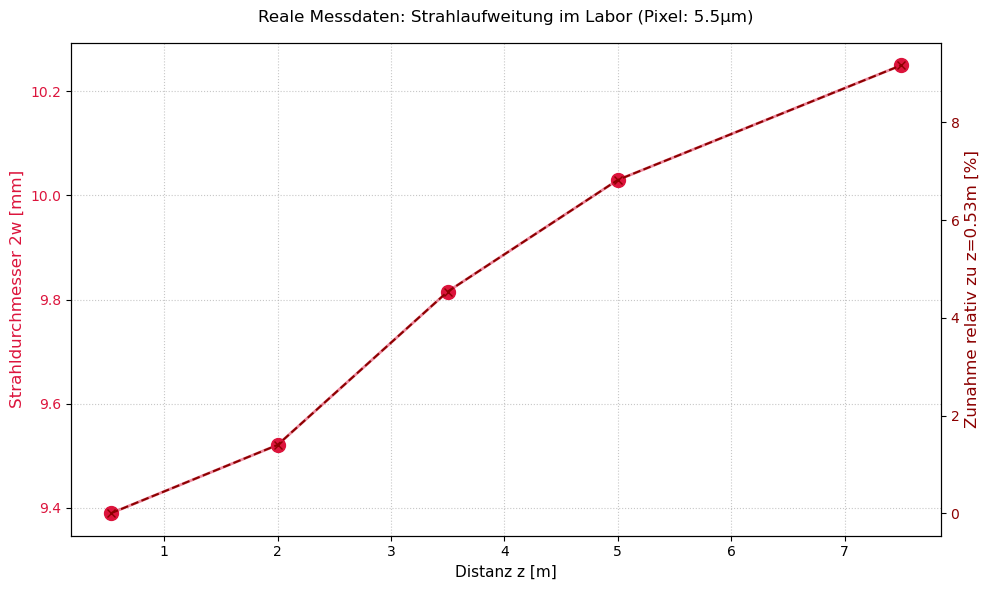

Abstand [m]  | Durchmesser [mm]   | Zunahme [%] 
--------------------------------------------------
       0.53m |            9.39 mm |       0.00 %
       2.00m |            9.52 mm |       1.40 %
       3.50m |            9.82 mm |       4.54 %
       5.00m |           10.03 mm |       6.82 %
       7.50m |           10.25 mm |       9.17 %


In [1]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ==============================================================
# 1) PARAMETER & SETUP
# ==============================================================
PIXEL_PITCH_UM = 5.5          # Kamera-Pixelgröße [µm]
px_to_m        = PIXEL_PITCH_UM * 1e-6
FAKTOR_REAL    = 2.0          # Gewünschte Verdopplung der Werte

# ==============================================================
# 2) FUNKTIONEN
# ==============================================================

def get_d4sigma_mm(I, spatial_dx):
    """Berechnet den D4sigma-Durchmesser in mm."""
    h, w_px = I.shape
    x_c = (np.arange(w_px) - w_px/2) * spatial_dx
    y_c = (np.arange(h) - h/2) * spatial_dx
    X, Y = np.meshgrid(x_c, y_c)
    
    total = np.sum(I)
    if total <= 0: return 0.0
    
    P = I / total
    cx = np.sum(X * P)
    cy = np.sum(Y * P)
    
    sigma_sq = 0.5 * (np.sum(P * (X - cx)**2) + np.sum(P * (Y - cy)**2))
    return 4 * np.sqrt(max(sigma_sq, 0)) * 1000 # Rückgabe in mm

def extract_distance_m(filename):
    """Extrahiert 'cm' aus dem Dateinamen und wandelt in Meter um."""
    m = re.search(r"(\d+(?:[.,]\d+)?)\s*cm", filename.lower())
    if m:
        return float(m.group(1).replace(",", ".")) / 100.0
    return None

# ==============================================================
# 3) DATEN AKQUISE & SORTIERUNG
# ==============================================================
base_dir = Path(".")
files = list(base_dir.glob("messung*.tiff"))
data_points = []

for p in files:
    z_m = extract_distance_m(p.name)
    if z_m is not None:
        img = np.array(Image.open(p), dtype=np.float64)
        img[img < 20] = 0 # Hintergrund-Threshold
        
        # Berechnung: (D4sigma in mm) * Faktor 2.0
        d_val = get_d4sigma_mm(img, px_to_m) * FAKTOR_REAL
        data_points.append((z_m, d_val))

# WICHTIG: Numerische Sortierung nach Distanz z
data_points.sort(key=lambda x: x[0])

z_real = np.array([pt[0] for pt in data_points])
d_real = np.array([pt[1] for pt in data_points])

# Berechnung der Steigerung [%] bezogen auf den ersten Messpunkt (z=0.53m)
if len(d_real) > 0:
    slope_pct = (d_real - d_real[0]) / d_real[0] * 100
else:
    slope_pct = np.array([])

# ==============================================================
# 4) PLOTTING
# ==============================================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Linke Achse: Absolute Messwerte [mm]
color_abs = 'crimson'
ax1.scatter(z_real, d_real, color=color_abs, s=100, label='Messpunkte (D4σ x2)', zorder=5)
ax1.plot(z_real, d_real, color=color_abs, ls='-', lw=2, alpha=0.5)

ax1.set_xlabel("Distanz z [m]", fontsize=11)
ax1.set_ylabel("Strahldurchmesser 2w [mm]", color=color_abs, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_abs)
ax1.grid(True, linestyle=':', alpha=0.7)

# Rechte Achse: Relative Steigung [%]
ax2 = ax1.twinx()
color_slope = 'darkred'
ax2.plot(z_real, slope_pct, color=color_slope, ls='--', marker='x', lw=1.5, label='Zunahme (%)')
ax2.set_ylabel("Zunahme relativ zu z=0.53m [%]", color=color_slope, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_slope)

plt.title(f"Reale Messdaten: Strahlaufweitung im Labor (Pixel: {PIXEL_PITCH_UM}µm)", pad=15)
fig.tight_layout()
plt.show()

# Tabellarische Ausgabe zur Kontrolle
print(f"{'Abstand [m]':<12} | {'Durchmesser [mm]':<18} | {'Zunahme [%]':<12}")
print("-" * 50)
for i in range(len(z_real)):
    print(f"{z_real[i]:>11.2f}m | {d_real[i]:>15.2f} mm | {slope_pct[i]:>10.2f} %")